# Fake News Detection 

### README:

### Requirements
- Python 3.8+
- PyTorch 2.0+
- Transformers 
- pandas, numpy, sklearn, matplotlib, seaborn

### Dataset
FakeNewsNet dataset (PolitiFact + GossipCop subsets)
- Place CSV files in `./dataset/` directory
- Expected format: columns for `text` and `label` (0=real, 1=fake)

### Quick Start

1. Run all cells in order
2. Training takes ~30-45 min on GPU (CUDA recommended)
3. Model saves to `multimodal_fake_news_detector.pt`

### Key Parameters
- Batch size: 8 (with gradient accumulation × 2)
- Max sequence length: 512 tokens
- Epochs: 15 (with early stopping)


## 1. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
import json
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
torch.cuda.empty_cache()

## 2. Dataset Preparation

### 2.1 Load FakeNewsNet Dataset from CSV

The FakeNewsNet dataset is available at: https://github.com/KaiDMML/FakeNewsNet

Dataset files:
- `dataset/gossipcop_fake.csv` - Fake news from GossipCop
- `dataset/gossipcop_real.csv` - Real news from GossipCop
- `dataset/politifact_fake.csv` - Fake news from PolitiFact
- `dataset/politifact_real.csv` - Real news from PolitiFact

Each CSV contains: news_id, title, text, url, etc.

In [3]:
# Configuration
FAKENEWSNET_PATH = './'
DATASET_PATH = os.path.join(FAKENEWSNET_PATH, 'dataset')



MAX_TEXT_LENGTH = 512
BATCH_SIZE = 8

print(f"Dataset path: {DATASET_PATH}")
print(f"Max text length: {MAX_TEXT_LENGTH} tokens")
print("Dataset path:", DATASET_PATH)
print("Files in dataset folder:", os.listdir(DATASET_PATH))

Dataset path: ./dataset
Max text length: 512 tokens
Dataset path: ./dataset
Files in dataset folder: ['gossipcop_fake.csv', 'gossipcop_real.csv', 'politifact_fake.csv', 'politifact_real.csv']


### 2.2 Load CSV and Build Dataset

In [4]:
# ============================================================================
# 2. Load FakeNewsNet Dataset (TEXT ONLY)
# ============================================================================

def load_fakenewsnet_data(dataset_path, samples_per_source=None):
    """
    Load FakeNewsNet dataset from CSV files (TEXT ONLY).
    
    Args:
        dataset_path: Path to FakeNewsNet/dataset directory
        samples_per_source: Dict mapping source names to max samples, or int for all sources
                          Example: {'gossipcop_real': 5000, 'gossipcop_fake': 5000}
                          Or simply: 5000 (applies to all sources)
    
    Returns:
        data_list: List of dictionaries with 'text', 'label'
    """
    data_list = []
    
    # Define CSV files and their labels (0=real, 1=fake)
    csv_files = [
        ('gossipcop_real.csv', 0),
        ('gossipcop_fake.csv', 1),
        ('politifact_real.csv', 0),
        ('politifact_fake.csv', 1),
    ]
    
    print("Loading FakeNewsNet TEXT datasets...")
    print("=" * 60)
    
    for csv_file, label in csv_files:
        csv_path = os.path.join(dataset_path, csv_file)
        source_name = csv_file.replace('.csv', '')
        
        if not os.path.exists(csv_path):
            print(f"Warning: {csv_file} not found at {csv_path}")
            continue
        
        try:
            df = pd.read_csv(csv_path)
            print(f"\nLoaded {csv_file}")
            print(f"  Columns: {df.columns.tolist()}")
            print(f"  Shape: {df.shape}")
            
            # Determine sample limit for this source
            if samples_per_source is not None:
                if isinstance(samples_per_source, dict):
                    max_samples = samples_per_source.get(source_name, len(df))
                else:
                    max_samples = samples_per_source
                
                if len(df) > max_samples:
                    df = df.sample(n=max_samples, random_state=42)
                    print(f"  Limited to {max_samples} samples")
            
            # FakeNewsNet CSV columns: ['id', 'news_url', 'title', 'tweet_ids']
            # Use 'text' or 'title' if available
            if 'text' in df.columns:
                text_column = 'text'
            elif 'title' in df.columns:
                text_column = 'title'
            else:
                # Fallback: first non-id, non-url column
                candidate_cols = [
                    c for c in df.columns
                    if 'id' not in c.lower() and 'url' not in c.lower()
                ]
                text_column = candidate_cols[0] if candidate_cols else df.columns[0]
            
            added_count = 0
            for _, row in df.iterrows():
                text = str(row[text_column]) if pd.notna(row[text_column]) else ""
                if not text or len(text.strip()) < 10:
                    continue
                
                data_list.append({
                    'text': text,
                    'label': label,
                })
                added_count += 1
            
            print(f"  Added {added_count} samples (cumulative: {len(data_list)})")
        
        except Exception as e:
            print(f"Error loading {csv_file}: {e}")
    
    print("\n" + "=" * 60)
    print(f"Total text samples loaded: {len(data_list)}")
    print(f"Real news: {sum(1 for d in data_list if d['label'] == 0)}")
    print(f"Fake news: {sum(1 for d in data_list if d['label'] == 1)}")
    print("=" * 60)
    
    return data_list


# Dataset size
samples_config = {
    'gossipcop_real': 5000,
    'gossipcop_fake': 5000,
    'politifact_real': None,   
    'politifact_fake': None     
}

# Load data
data_list = load_fakenewsnet_data(DATASET_PATH, samples_per_source=samples_config)


Loading FakeNewsNet TEXT datasets...

Loaded gossipcop_real.csv
  Columns: ['id', 'news_url', 'title', 'tweet_ids']
  Shape: (16817, 4)
  Limited to 5000 samples
  Added 5000 samples (cumulative: 5000)

Loaded gossipcop_fake.csv
  Columns: ['id', 'news_url', 'title', 'tweet_ids']
  Shape: (5323, 4)
  Limited to 5000 samples
  Added 5000 samples (cumulative: 10000)

Loaded politifact_real.csv
  Columns: ['id', 'news_url', 'title', 'tweet_ids']
  Shape: (624, 4)
Error loading politifact_real.csv: '>' not supported between instances of 'int' and 'NoneType'

Loaded politifact_fake.csv
  Columns: ['id', 'news_url', 'title', 'tweet_ids']
  Shape: (432, 4)
Error loading politifact_fake.csv: '>' not supported between instances of 'int' and 'NoneType'

Total text samples loaded: 10000
Real news: 5000
Fake news: 5000


### 2.3 Define Custom Dataset Class

In [5]:
class TextFakeNewsDataset(Dataset):
    """
    Text-only dataset for fake news detection using BERT.
    """
    def __init__(self, data_list, max_text_length=128, tokenizer=None):
        self.data_list = data_list
        self.max_text_length = max_text_length
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        data = self.data_list[idx]
        text = data['text']
        label = data['label']
    
        encoding = self.tokenizer(
            text,
            max_length=self.max_text_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
    
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        label_tensor = torch.tensor(label, dtype=torch.long)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'label': label_tensor
        }

### 2.4 Split Data and Create DataLoaders

In [6]:
# Initialize BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("BERT tokenizer loaded")

# Shuffle data
np.random.shuffle(data_list)

# Split data into train/val/test (60/20/20)
total_samples = len(data_list)
train_size = int(0.6 * total_samples)
val_size = int(0.2 * total_samples)

train_data = data_list[:train_size]
val_data = data_list[train_size:train_size + val_size]
test_data = data_list[train_size + val_size:]

print(f"\nData split: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

# Check class balance
train_real = sum(1 for d in train_data if d['label'] == 0)
train_fake = sum(1 for d in train_data if d['label'] == 1)
print(f"Training set: {train_real} real, {train_fake} fake")

# Create dataset instances
train_dataset = TextFakeNewsDataset(train_data, max_text_length=MAX_TEXT_LENGTH, tokenizer=tokenizer)
val_dataset = TextFakeNewsDataset(val_data, max_text_length=MAX_TEXT_LENGTH, tokenizer=tokenizer)
test_dataset = TextFakeNewsDataset(test_data, max_text_length=MAX_TEXT_LENGTH, tokenizer=tokenizer)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print("\nDataLoaders created:")
print(f" Train batches: {len(train_loader)}")
print(f" Val batches: {len(val_loader)}")
print(f" Test batches: {len(test_loader)}")

BERT tokenizer loaded

Data split: Train=6000, Val=2000, Test=2000
Training set: 3062 real, 2938 fake

DataLoaders created:
 Train batches: 750
 Val batches: 250
 Test batches: 250


## 3. Model Architecture

### 3.1 Text Encoder (BERT)

In [7]:
class TextEncoder(nn.Module):
    """
    BERT-based text encoder for extracting semantic text features.
    Uses [CLS] token representation as sentence embedding.
    """
    
    def __init__(self, model_name='bert-base-uncased'):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.output_dim = self.bert.config.hidden_size  # 768

    
    def forward(self, input_ids, attention_mask):
        """
        Extract text features using BERT.
        
        Args:
            input_ids: (batch_size, seq_length)
            attention_mask: (batch_size, seq_length)
        
        Returns:
            cls_features: (batch_size, 768) - [CLS] token representation
        """
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Use [CLS] token (first token) as sentence representation
        cls_features = outputs.last_hidden_state[:, 0, :]  # (batch_size, 768)
        return cls_features

print("TextEncoder defined")


TextEncoder defined


### 3.2 Classification Head
The classification head is a small multi-layer perceptron that maps the BERT [CLS] embedding to a binary prediction (real vs fake).

In [8]:
class ClassificationHead(nn.Module):
    """
    Classification head: Multi-layer perceptron with dropout for final prediction.
    """
    
    def __init__(self, input_dim=768, hidden_dim=384, output_dim=2, dropout=0.5):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
            )
    
    def forward(self, features):
        """
        Predict fake news label.
        
        Args:
            features: (batch_size, 768)
        
        Returns:
            logits: (batch_size, 2)
        """
        logits = self.mlp(features)
        return logits

print("ClassificationHead defined")

ClassificationHead defined


### 3.3 Complete Model

In [9]:
class TextFakeNewsClassifier(nn.Module):
    
    def __init__(self, model_name='bert-base-uncased', dropout=0.3):
        super().__init__()
        self.text_encoder = TextEncoder(model_name=model_name)
        self.classifier = ClassificationHead(
            input_dim=self.text_encoder.output_dim,
            hidden_dim=self.text_encoder.output_dim // 2,
            output_dim=2,
            dropout=dropout
        )
    
    def forward(self, input_ids, attention_mask):
        """
        Args:
            input_ids: (batch_size, seq_length)
            attention_mask: (batch_size, seq_length)
    
        Returns:
            logits: (batch_size, 2)
        """
        text_features = self.text_encoder(input_ids, attention_mask)
        logits = self.classifier(text_features)
        return logits
print("\n" + "="*60)
print("TEXT-ONLY FAKE NEWS DETECTOR ARCHITECTURE")
print("="*60)
print("Text Encoder: BERT-base ([CLS] 768-dim representation)")
print("Classifier: MLP with GELU activations and dropout")
print("="*60)





TEXT-ONLY FAKE NEWS DETECTOR ARCHITECTURE
Text Encoder: BERT-base ([CLS] 768-dim representation)
Classifier: MLP with GELU activations and dropout


## 4. Training Setup

### 4.1 Initialize Model and Optimizer

In [10]:
import torch
import gc
import os

# Set environment variable to clear CUDA cache
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:512'

# Complete reset
torch.cuda.empty_cache()
torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
gc.collect()

# Verify clean state
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")


GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB
GPU available: True
GPU name: NVIDIA GeForce RTX 4090


In [11]:
# ============================================================================
# 4.1 Initialize Model and Creative Fine-tuning Components
# ============================================================================

# Initialize model
model = TextFakeNewsClassifier(model_name='bert-base-uncased', dropout=0.5)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)


# Layer-wise Learning Rates 


# 1. Classifier head (custom layer)
classifier_params = list(model.classifier.parameters())

# 2. Top BERT layers (8-11) - learn task-specific patterns
top_layers_params = []
for i in range(8, 12):
    top_layers_params.extend(list(model.text_encoder.bert.encoder.layer[i].parameters()))

# 3. Bottom BERT layers (0-7) - fine-tune general features
bottom_layers_params = []
for i in range(0, 8):
    bottom_layers_params.extend(list(model.text_encoder.bert.encoder.layer[i].parameters()))

# 4. Embeddings + Pooler - learn word representations
embedding_params = list(model.text_encoder.bert.embeddings.parameters())
pooler_params = list(model.text_encoder.bert.pooler.parameters())

# Define layer-wise learning rates (different rates for different depths)
LR_CLASSIFIER = 2e-5      # Highest - learns from scratch
LR_TOP_BERT = 1e-5        # High - adapts to task
LR_BOTTOM_BERT = 5e-6     # Low - preserves pretrained knowledge  
LR_EMBEDDINGS = 3e-6      # Lowest - careful with word meanings

# Create optimizer with ALL layers
optimizer = optim.AdamW([
    {'params': classifier_params, 'lr': LR_CLASSIFIER, 'name': 'classifier'},
    {'params': top_layers_params, 'lr': LR_TOP_BERT, 'name': 'top_bert_layers'},
    {'params': bottom_layers_params, 'lr': LR_BOTTOM_BERT, 'name': 'bottom_bert_layers'},
    {'params': embedding_params + pooler_params, 'lr': LR_EMBEDDINGS, 'name': 'embeddings'}
], weight_decay=1e-4)

print("\nOptimizer groups:")
for group in optimizer.param_groups:
    print(f"  {group['name']}: LR={group['lr']}, params={sum(p.numel() for p in group['params']):,}")

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.2):
        super().__init__()
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing
        
    def forward(self, pred, target):
        pred = pred.log_softmax(dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (pred.size(-1) - 1))
            true_dist.scatter_(1, target.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * pred, dim=-1))

criterion = LabelSmoothingCrossEntropy(smoothing=0.15)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.35,
    patience=2,
    verbose=True,
    min_lr=1e-7
)

print("\n Fine-tuning setup complete!")



Optimizer groups:
  classifier: LR=2e-05, params=296,066
  top_bert_layers: LR=1e-05, params=28,351,488
  bottom_bert_layers: LR=5e-06, params=56,702,976
  embeddings: LR=3e-06, params=24,427,776

 Fine-tuning setup complete!


### 4.2 Training and Evaluation Functions

In [12]:
# Add at top with your config
GRADIENT_ACCUMULATION_STEPS = 2
DECISION_THRESHOLD = 0.50  # Default, will be optimized later

def train_epoch(model, dataloader, optimizer, criterion, device):
    # Keep your existing code unchanged
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    optimizer.zero_grad()
    
    for batch_idx, batch in enumerate(tqdm(dataloader, desc="Training")):
        input_ids = batch['input_ids'].to(device, non_blocking=True)
        attention_mask = batch['attention_mask'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)
        
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss = loss / GRADIENT_ACCUMULATION_STEPS
        loss.backward()
        
        if (batch_idx + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
            optimizer.step()
            optimizer.zero_grad()
        
        total_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS
        _, predicted = torch.max(logits, 1)  # Default 0.5 for training monitoring
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    if (batch_idx + 1) % GRADIENT_ACCUMULATION_STEPS != 0:
        optimizer.step()
        optimizer.zero_grad()
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device, threshold=None):
    """
    Evaluation with optional custom threshold.
    If threshold=None, uses argmax (equivalent to 0.5).
    """
    global DECISION_THRESHOLD  # Use global threshold variable
    if threshold is None:
        threshold = DECISION_THRESHOLD
    
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            
            # Use threshold if specified, otherwise argmax
            if threshold != 0.50:  # Custom threshold
                probs = torch.softmax(logits, dim=1)[:, 1]
                predicted = (probs >= threshold).long()
            else:  # Default behavior
                _, predicted = torch.max(logits, 1)
            
            total_loss += loss.item()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy, all_predictions, all_labels

print(f"Effective batch size: {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"Initial decision threshold: {DECISION_THRESHOLD}")


Effective batch size: 16
Initial decision threshold: 0.5


### 4.3 Early Stopping

In [13]:
class EarlyStopping:
    """
    Early stopping to prevent overfitting.
    """
    
    def __init__(self, patience=5, verbose=True, delta=0.001):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_wts = None
    
    def __call__(self, val_acc, model):
        """
        Call early stopping check.
        Returns True if training should stop.
        """
        if self.best_score is None:
            self.best_score = val_acc
            self.best_model_wts = model.state_dict()
        elif val_acc > self.best_score + self.delta:
            self.best_score = val_acc
            self.counter = 0
            self.best_model_wts = model.state_dict()
        else:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        
        return self.early_stop

print("EarlyStopping class defined")

EarlyStopping class defined


## 5. Training Loop

In [14]:

import gc

torch.cuda.empty_cache()
gc.collect()

def check_gpu_memory():
    if torch.cuda.is_available():
        print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
        print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
        print(f"GPU memory total: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

check_gpu_memory()

GPU memory allocated: 0.41 GB
GPU memory reserved: 0.46 GB
GPU memory total: 23.52 GB


In [15]:
# Training configuration
device = torch.device( "cuda")
NUM_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3

# Initialize early stopping
early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, verbose=True, delta=0.0)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
}

best_val_acc = 0

print(f"\nStarting training for {NUM_EPOCHS} epochs...")
print("="*60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    # Training
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    
    # Validation
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nEpoch Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Learning rate scheduling
    scheduler.step(val_acc)
    
    # Early stopping
    if early_stopping(val_acc, model):
        print(f"\nEarly stopping at epoch {epoch+1}")
        # Load best model weights
        model.load_state_dict(early_stopping.best_model_wts)
        break
    
    # Track best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_text_model.pt')
        print(f"  Best model saved (Val Acc: {best_val_acc:.4f})")


print("Training completed!")



Starting training for 15 epochs...

Epoch 1/15


Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:14<00:00, 16.94it/s]



Epoch Summary:
  Train Loss: 0.6480 | Train Acc: 0.6715
  Val Loss: 0.6003 | Val Acc: 0.7710
  Best model saved (Val Acc: 0.7710)

Epoch 2/15


Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:14<00:00, 16.97it/s]



Epoch Summary:
  Train Loss: 0.5858 | Train Acc: 0.7928
  Val Loss: 0.5834 | Val Acc: 0.7995
  Best model saved (Val Acc: 0.7995)

Epoch 3/15


...


Epoch Summary:
  Train Loss: 0.4724 | Train Acc: 0.9505
  Val Loss: 0.6091 | Val Acc: 0.7955
EarlyStopping counter: 1/3

Epoch 8/15


Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:14<00:00, 16.78it/s]



Epoch Summary:
  Train Loss: 0.4608 | Train Acc: 0.9643
  Val Loss: 0.6209 | Val Acc: 0.7875
EarlyStopping counter: 2/3

Epoch 9/15


Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:14<00:00, 16.82it/s]



Epoch Summary:
  Train Loss: 0.4557 | Train Acc: 0.9682
  Val Loss: 0.6421 | Val Acc: 0.7810
EarlyStopping counter: 3/3

Early stopping at epoch 9
Training completed!



Sweeping decision thresholds on VALIDATION set...
Threshold: 0.30 | Acc: 0.766 | Prec: 0.719 | Rec: 0.903 | F1: 0.801
Threshold: 0.35 | Acc: 0.769 | Prec: 0.728 | Rec: 0.889 | F1: 0.800
Threshold: 0.40 | Acc: 0.776 | Prec: 0.741 | Rec: 0.877 | F1: 0.803
Threshold: 0.45 | Acc: 0.780 | Prec: 0.750 | Rec: 0.868 | F1: 0.804
Threshold: 0.50 | Acc: 0.781 | Prec: 0.753 | Rec: 0.862 | F1: 0.804
Threshold: 0.55 | Acc: 0.783 | Prec: 0.760 | Rec: 0.855 | F1: 0.805
Threshold: 0.60 | Acc: 0.786 | Prec: 0.765 | Rec: 0.851 | F1: 0.806
Threshold: 0.65 | Acc: 0.790 | Prec: 0.775 | Rec: 0.843 | F1: 0.807
Threshold: 0.70 | Acc: 0.795 | Prec: 0.789 | Rec: 0.827 | F1: 0.808
Threshold: 0.75 | Acc: 0.798 | Prec: 0.802 | Rec: 0.814 | F1: 0.808

Optimal threshold (best F1-score): 0.70
   Accuracy: 0.795
   Precision: 0.789
   Recall: 0.827
   F1-Score: 0.808

[Alternative] High-recall threshold (≥85% recall): 0.60
   Accuracy: 0.786, Precision: 0.765, Recall: 0.851, F1: 0.806


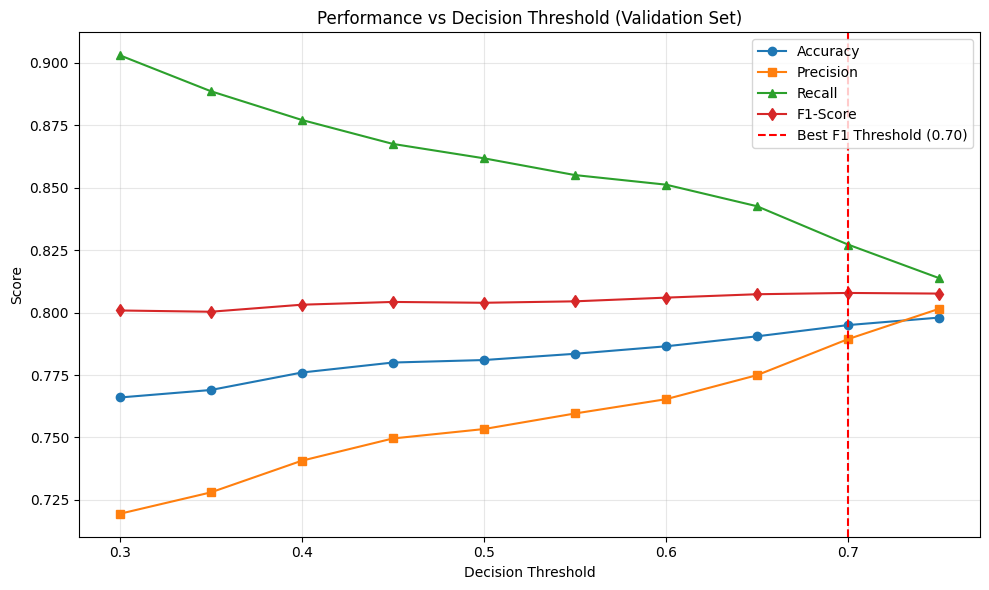


Threshold tuning plot saved as 'threshold_tuning.png'

Updating decision threshold based on validation sweep
New threshold: 0.70

Evaluating on test set with optimized threshold (0.70)...


Validation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:14<00:00, 16.74it/s]



FINAL TEST SET PERFORMANCE (Threshold=0.70)
Loss:      0.6686
Accuracy:  0.7720
Precision: 0.7541
Recall:    0.8206
F1-Score:  0.7859


In [19]:
# Confidence-based Threshold Tuning

def evaluate_with_threshold(model, dataloader, threshold, device):
    """
    Evaluate model with custom decision threshold.
    Instead of default 0.5, we can tune to favor recall or precision.
    """
    model.eval()
    all_predictions = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(input_ids, attention_mask)
            probs = torch.softmax(logits, dim=1)[:, 1]  # Probability of "fake"
            
            # Apply custom threshold
            predicted = (probs >= threshold).long()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    # Compute metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    
    return accuracy, precision, recall, f1, all_probs

# Sweep thresholds
thresholds = np.arange(0.3, 0.8, 0.05)
results = []

print("\nSweeping decision thresholds on VALIDATION set...")
for threshold in thresholds:
    acc, prec, rec, f1, _ = evaluate_with_threshold(model, val_loader, threshold, device)
    results.append({
        'threshold': threshold,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    })
    print(f"Threshold: {threshold:.2f} | Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}")

# Convert to DataFrame
import pandas as pd
results_df = pd.DataFrame(results)

# SIMPLIFIED: Just pick best F1-score
best_threshold_row = results_df.loc[results_df['f1'].idxmax()]
print(f"\nOptimal threshold (best F1-score): {best_threshold_row['threshold']:.2f}")
print(f"   Accuracy: {best_threshold_row['accuracy']:.3f}")
print(f"   Precision: {best_threshold_row['precision']:.3f}")
print(f"   Recall: {best_threshold_row['recall']:.3f}")
print(f"   F1-Score: {best_threshold_row['f1']:.3f}")

# OPTIONAL: Also show high-recall option for comparison
high_recall_results = results_df[results_df['recall'] >= 0.85]
if len(high_recall_results) > 0:
    high_recall_best = high_recall_results.loc[high_recall_results['precision'].idxmax()]
    print(f"\n[Alternative] High-recall threshold (≥85% recall): {high_recall_best['threshold']:.2f}")
    print(f"   Accuracy: {high_recall_best['accuracy']:.3f}, Precision: {high_recall_best['precision']:.3f}, Recall: {high_recall_best['recall']:.3f}, F1: {high_recall_best['f1']:.3f}")

# Plot threshold curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(results_df['threshold'], results_df['accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['threshold'], results_df['precision'], marker='s', label='Precision')
plt.plot(results_df['threshold'], results_df['recall'], marker='^', label='Recall')
plt.plot(results_df['threshold'], results_df['f1'], marker='d', label='F1-Score')

# Mark the best F1 threshold
plt.axvline(x=best_threshold_row['threshold'], color='red', linestyle='--', 
            label=f"Best F1 Threshold ({best_threshold_row['threshold']:.2f})")

plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Performance vs Decision Threshold (Validation Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nThreshold tuning plot saved as 'threshold_tuning.png'")

# Update global threshold
print("\n" + "="*60)
print("Updating decision threshold based on validation sweep")
print("="*60)

DECISION_THRESHOLD = best_threshold_row['threshold']  # Will be 0.70 or 0.75
print(f"New threshold: {DECISION_THRESHOLD:.2f}")

# Evaluate on test set with optimized threshold
print(f"\nEvaluating on test set with optimized threshold ({DECISION_THRESHOLD:.2f})...")
test_loss, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device, threshold=DECISION_THRESHOLD
)

precision = precision_score(test_labels, test_preds, zero_division=0)
recall = recall_score(test_labels, test_preds, zero_division=0)
f1 = f1_score(test_labels, test_preds, zero_division=0)

print("\n" + "="*60)
print(f"FINAL TEST SET PERFORMANCE (Threshold={DECISION_THRESHOLD:.2f})")
print("="*60)
print(f"Loss:      {test_loss:.4f}")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*60)


## 6. Evaluation & Results Analysis

### 6.1 Visualizations

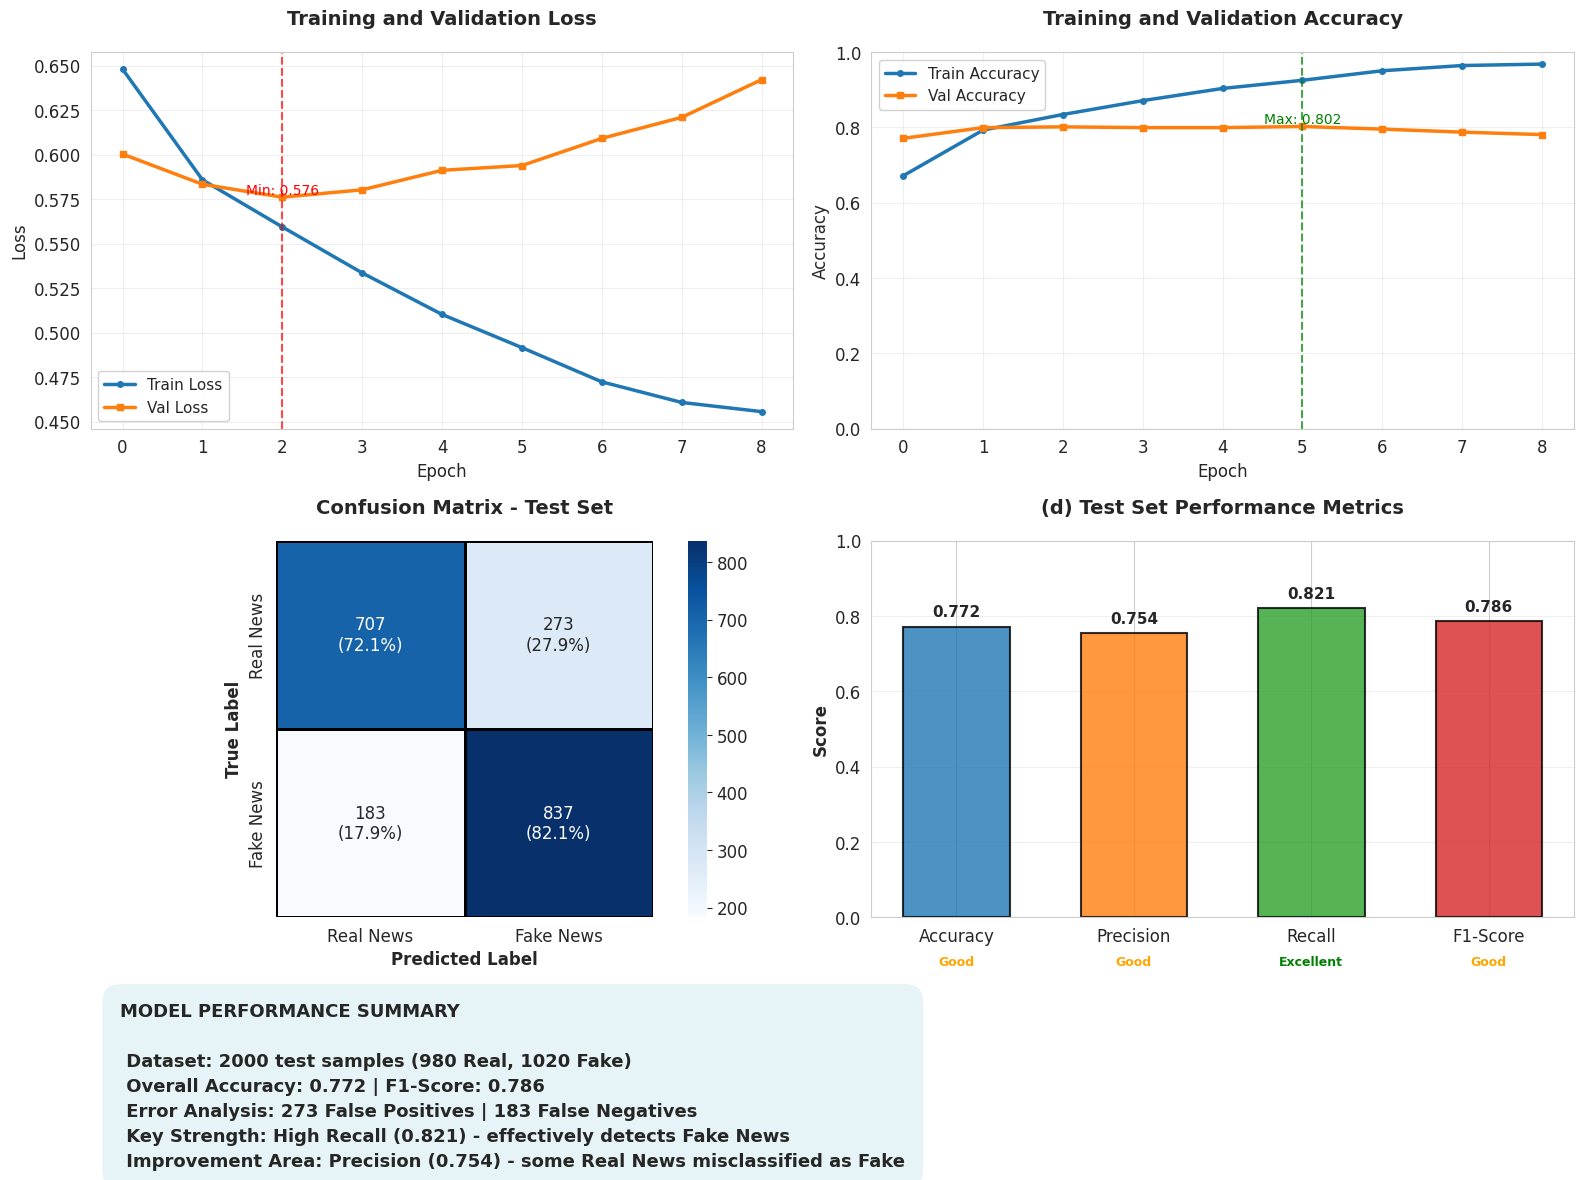

In [20]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 12

# Create the figure with better layout
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 0.3])

# 1. Training and Validation Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2.5, marker='o', markersize=4, color='#1f77b4')
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2.5, marker='s', markersize=4, color='#ff7f0e')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold', pad=20)
ax1.legend(fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3)
# Add min loss annotation
min_val_loss = min(history['val_loss'])
min_val_epoch = history['val_loss'].index(min_val_loss)
ax1.axvline(x=min_val_epoch, color='red', linestyle='--', alpha=0.7)
ax1.text(min_val_epoch, min_val_loss, f'Min: {min_val_loss:.3f}', 
         ha='center', va='bottom', fontsize=10, color='red')

# Training and Validation Accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history['train_acc'], label='Train Accuracy', linewidth=2.5, marker='o', markersize=4, color='#1f77b4')
ax2.plot(history['val_acc'], label='Val Accuracy', linewidth=2.5, marker='s', markersize=4, color='#ff7f0e')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold', pad=20)
ax2.legend(fontsize=11, framealpha=0.9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])
# Add max accuracy annotation
max_val_acc = max(history['val_acc'])
max_val_epoch = history['val_acc'].index(max_val_acc)
ax2.axvline(x=max_val_epoch, color='green', linestyle='--', alpha=0.7)
ax2.text(max_val_epoch, max_val_acc, f'Max: {max_val_acc:.3f}', 
         ha='center', va='bottom', fontsize=10, color='green')

# Confusion Matrix with percentages
ax3 = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(test_labels, test_preds)
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create annotation labels with both counts and percentages
annot = np.array([["{0:d}\n({1:.1f}%)".format(count, percentage) 
                   for count, percentage in zip(row, percentage_row)] 
                  for row, percentage_row in zip(cm, cm_percentage)])

sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=True, ax=ax3,
            xticklabels=['Real News', 'Fake News'], 
            yticklabels=['Real News', 'Fake News'],
            square=True, linewidths=1, linecolor='black')
ax3.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax3.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax3.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=20)

# 4. Detailed Metrics Comparison
ax4 = fig.add_subplot(gs[1, 1])
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [test_acc, precision, recall, f1]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = ax4.bar(metrics, values, color=colors, alpha=0.8, 
               edgecolor='black', linewidth=1.5, width=0.6)
ax4.set_ylabel('Score', fontsize=12, fontweight='bold')
ax4.set_title('(d) Test Set Performance Metrics', fontsize=14, fontweight='bold', pad=20)
ax4.set_ylim([0, 1])
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels and performance indicators
for bar, value, metric in zip(bars, values, metrics):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{value:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Add performance rating
    if value >= 0.8:
        rating = "Excellent"
        color = "green"
    elif value >= 0.7:
        rating = "Good"
        color = "orange"
    else:
        rating = "Needs Improvement"
        color = "red"
    
    ax4.text(bar.get_x() + bar.get_width()/2., -0.1,
            rating, ha='center', va='top', fontsize=9, color=color, 
            fontweight='bold', rotation=0)

# 5. Summary Statistics
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')

# Calculate additional statistics
total_samples = len(test_labels)
fake_news_count = sum(test_labels)
real_news_count = total_samples - fake_news_count
false_positives = cm[0, 1]  # Real news predicted as fake
false_negatives = cm[1, 0]  # Fake news predicted as real

summary_text = (
    f"MODEL PERFORMANCE SUMMARY\n\n"
    f" Dataset: {total_samples} test samples ({real_news_count} Real, {fake_news_count} Fake)\n"
    f" Overall Accuracy: {test_acc:.3f} | F1-Score: {f1:.3f}\n"
    f" Error Analysis: {false_positives} False Positives | {false_negatives} False Negatives\n"
    f" Key Strength: High Recall ({recall:.3f}) - effectively detects Fake News\n"
    f" Improvement Area: Precision ({precision:.3f}) - some Real News misclassified as Fake"
)

ax5.text(0.02, 0.5, summary_text, fontsize=13, fontweight='bold',
         verticalalignment='center', linespacing=1.5,
         bbox=dict(boxstyle="round,pad=1", facecolor="lightblue", alpha=0.3))

plt.tight_layout()
plt.savefig('comprehensive_model_evaluation.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### 6.3 Prediction Distribution

Probability distribution plot saved as 'text_model_probability_distribution.png'


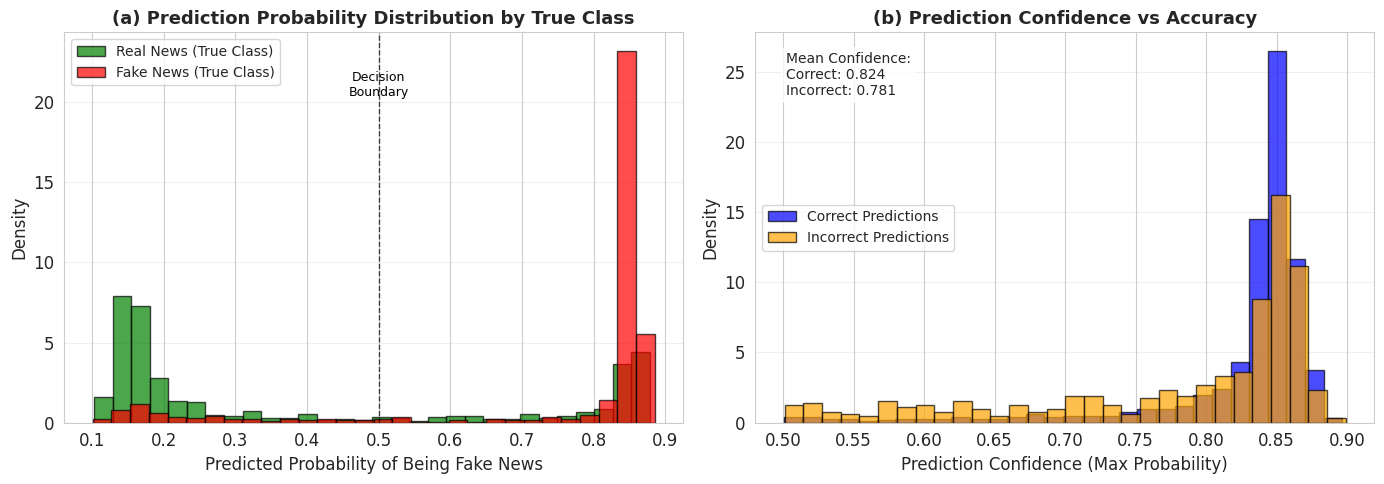

In [21]:
# Get prediction probabilities 
model.eval()
all_probs = []
test_labels = []
test_preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
     
        logits = model(input_ids, attention_mask)  
        probs = torch.softmax(logits, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

all_probs = np.array(all_probs)
test_labels = np.array(test_labels)
test_preds = np.array(test_preds)
fake_probs = all_probs[:, 1]  # Probability of fake class

# Plot probability distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution by true class
ax = axes[0]
real_mask = (test_labels == 0)
fake_mask = (test_labels == 1)

ax.hist(fake_probs[real_mask], bins=30, alpha=0.7, label='Real News (True Class)', 
        color='green', edgecolor='black', density=True)
ax.hist(fake_probs[fake_mask], bins=30, alpha=0.7, label='Fake News (True Class)', 
        color='red', edgecolor='black', density=True)

ax.set_xlabel('Predicted Probability of Being Fake News', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('(a) Prediction Probability Distribution by True Class', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add vertical line at decision boundary
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.7, linewidth=1)
ax.text(0.5, ax.get_ylim()[1]*0.9, 'Decision\nBoundary', 
        ha='center', va='top', fontsize=9, color='black')

# 2. Prediction confidence analysis
ax = axes[1]
confidence = np.max(all_probs, axis=1)
correct = (test_preds == test_labels)

ax.hist(confidence[correct], bins=30, alpha=0.7, label='Correct Predictions', 
        color='blue', edgecolor='black', density=True)
ax.hist(confidence[~correct], bins=30, alpha=0.7, label='Incorrect Predictions', 
        color='orange', edgecolor='black', density=True)

ax.set_xlabel('Prediction Confidence (Max Probability)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('(b) Prediction Confidence vs Accuracy', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Calculate and display confidence statistics
mean_conf_correct = np.mean(confidence[correct]) if np.any(correct) else 0
mean_conf_incorrect = np.mean(confidence[~correct]) if np.any(~correct) else 0

ax.text(0.05, 0.95, f'Mean Confidence:\nCorrect: {mean_conf_correct:.3f}\nIncorrect: {mean_conf_incorrect:.3f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('text_model_probability_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
print("Probability distribution plot saved as 'text_model_probability_distribution.png'")
plt.show()

## 7. Model Saving & Summary

In [22]:
# Save final model
torch.save(model.state_dict(), 'multimodal_fake_news_detector.pt')
print("Model saved as 'multimodal_fake_news_detector.pt'")

# Save training history
import json
with open('training_history.json', 'w') as f:
    json.dump(history, f, indent=4)
print("Training history saved as 'training_history.json'")

# Save results summary
results = {
    'test_metrics': {
        'loss': float(test_loss),
        'accuracy': float(test_acc),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1)
    },
    'best_val_accuracy': float(best_val_acc),
    'epochs_trained': epoch + 1,
    'model_config': {
        'embedding_dim': 768,
        'num_fusion_layers': 2,
        'dropout': 0.3,
        'total_parameters': int(total_params)
    },
    'dataset_info': {
        'total_samples': len(data_list),
        'train_samples': len(train_data),
        'val_samples': len(val_data),
        'test_samples': len(test_data)
    }
}

with open('results_summary.json', 'w') as f:
    json.dump(results, f, indent=4)
print("Results summary saved as 'results_summary.json'")

Model saved as 'multimodal_fake_news_detector.pt'
Training history saved as 'training_history.json'
Results summary saved as 'results_summary.json'


## 8. Inference & Prediction Examples

In [31]:
def decode_sample_text(sample, tokenizer):
    input_ids = sample['input_ids']
    non_padding_tokens = input_ids[input_ids != 0]
    content_tokens = non_padding_tokens[(non_padding_tokens != 101) & (non_padding_tokens != 102)]
    text = tokenizer.decode(content_tokens, skip_special_tokens=True)
    return text

def demonstrate_predictions_corrected(model, test_dataset, tokenizer, device, num_samples=3):
    
    print(f"\nTesting on {num_samples} random samples from test set:\n")
    
    for i in range(num_samples):
        sample_idx = np.random.randint(0, len(test_dataset))
        sample = test_dataset[sample_idx]
        

        text = decode_sample_text(sample, tokenizer)
        true_label = sample['label'].item()
        
        print(f"{'='*50}")
        print(f"SAMPLE {i+1}:")
        print(f"{'='*50}")
        print(f"Text: {text[:150]}..." if len(text) > 150 else f"Text: {text}")
        print(f"True Label: {['Real News', 'Fake News'][true_label]}")
        
        model.eval()
        with torch.no_grad():
            input_ids = sample['input_ids'].unsqueeze(0).to(device)  # 添加batch維度
            attention_mask = sample['attention_mask'].unsqueeze(0).to(device)
            
            logits = model(input_ids, attention_mask)
            probs = torch.softmax(logits, dim=1)
            prediction = torch.argmax(probs, dim=1).item()
            confidence = probs.max().item()
            probabilities = probs.cpu().numpy()[0]
        
        print(f"\nModel Prediction:")
        print(f"  • Predicted: {['Real News', 'Fake News'][prediction]}")
        print(f"  • Confidence: {confidence:.4f}")
        print(f"  • Probabilities: [Real: {probabilities[0]:.4f}, Fake: {probabilities[1]:.4f}]")
        
        correct = prediction == true_label
        print(f"  • Correct: {'✓' if correct else '✗'}")
        
        # Confidence analysis
        if correct:
            if confidence > 0.75:
                print(f"  • Analysis: High confidence correct prediction")
            else:
                print(f"  • Analysis: Correct but low confidence")
        else:
            if confidence > 0.75:
                print(f"  • Analysis: High confidence incorrect prediction")
            else:
                print(f"  • Analysis: Incorrect with low confidence")
        print()

demonstrate_predictions_corrected(model, test_dataset, tokenizer, device, num_samples=3)


Testing on 3 random samples from test set:

SAMPLE 1:
Text: kristen stewart replaced angelina jolie in movie report a year ago
True Label: Fake News

Model Prediction:
  • Predicted: Fake News
  • Confidence: 0.8429
  • Probabilities: [Real: 0.1571, Fake: 0.8429]
  • Correct: ✓
  • Analysis: High confidence correct prediction

SAMPLE 2:
Text: karrueche tran - - screw chris brown... i can post pics of whoever i want ( video )
True Label: Fake News

Model Prediction:
  • Predicted: Fake News
  • Confidence: 0.8532
  • Probabilities: [Real: 0.1468, Fake: 0.8532]
  • Correct: ✓
  • Analysis: High confidence correct prediction

SAMPLE 3:
Text: ben affleck called a'pig'after rumors surface he's ready to marry girlfriend lindsay shookus
True Label: Fake News

Model Prediction:
  • Predicted: Fake News
  • Confidence: 0.8530
  • Probabilities: [Real: 0.1470, Fake: 0.8530]
  • Correct: ✓
  • Analysis: High confidence correct prediction



In [47]:
import re

print("\n" + "="*70)
print("INTERACTIVE FAKE NEWS DETECTOR")
print("Real-time analysis with red flag detection")
print("="*70)

class TitleFakeNewsAnalyzer:
    """
    Analyzer specifically for news TITLES (headlines).
    Detects fake news patterns and provides interactive feedback.
    """
    
    # Red flag patterns for headlines (based on common fake news patterns)
    SENSATIONAL_WORDS = [
        'shocking', 'unbelievable', 'miracle', 'secret', 'hidden', 
        'exposed', 'truth', 'revealed', 'bombshell', 'scandal',
        'you won\'t believe', 'must see', 'breaking', 'urgent'
    ]
    
    CLICKBAIT_PATTERNS = [
        r'click here', r'share now', r'find out', r'what happens',
        r'number \d+ will', r'this one', r'why \w+ (hate|love)',
        r'\d+ (reasons|ways|things)', r'before (it\'s|they)'
    ]
    
    EMOTIONAL_WORDS = [
        'outraged', 'furious', 'devastated', 'terrified', 'panic',
        'horrifying', 'disgusting', 'betrayed', 'shocking', 'stunning'
    ]
    
    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
    
    def analyze_title(self, title):
        """Comprehensive analysis of news headline."""
        # Get model prediction
        prediction, confidence, probs = self._get_prediction(title)
        
        # Detect red flags
        red_flags = self._detect_red_flags(title)
        
        # Calculate risk score
        risk_score = self._calculate_risk_score(red_flags, probs[1])
        
        return {
            'title': title,
            'prediction': prediction,
            'confidence': confidence,
            'probabilities': probs,
            'red_flags': red_flags,
            'risk_score': risk_score
        }
    
    def _get_prediction(self, title):
        """Get model prediction for title."""
        self.model.eval()
        
        encoding = self.tokenizer(
            title,
            max_length=512,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].to(self.device)
        attention_mask = encoding['attention_mask'].to(self.device)
        
        with torch.no_grad():
            logits = self.model(input_ids, attention_mask)
            probabilities = torch.softmax(logits, dim=1)[0]
            prob_real = probabilities[0].item()
            prob_fake = probabilities[1].item()
        
        prediction = "FAKE" if prob_fake > 0.5 else "REAL"
        confidence = prob_fake if prediction == "FAKE" else prob_real
        
        return prediction, confidence, [prob_real, prob_fake]
    
    def _detect_red_flags(self, title):
        """Detect red flag patterns in headline."""
        red_flags = []
        title_lower = title.lower()
        
        # 1. Excessive punctuation
        exclamation_count = title.count('!')
        question_count = title.count('?')
        if exclamation_count > 1:
            red_flags.append({
                'type': 'Excessive Punctuation',
                'severity': 'Medium',
                'detail': f'{exclamation_count} exclamation marks'
            })
        
        # 2. All caps words
        caps_words = re.findall(r'\b[A-Z]{3,}\b', title)
        if len(caps_words) > 1:
            red_flags.append({
                'type': 'Shouting (All Caps)',
                'severity': 'High',
                'detail': f'Found: {", ".join(caps_words)}'
            })
        
        # 3. Sensational language
        sensational_found = [w for w in self.SENSATIONAL_WORDS if w in title_lower]
        if sensational_found:
            red_flags.append({
                'type': 'Sensational Language',
                'severity': 'High',
                'detail': f'Words: {", ".join(sensational_found[:3])}'
            })
        
        # 4. Clickbait patterns
        for pattern in self.CLICKBAIT_PATTERNS:
            if re.search(pattern, title_lower):
                red_flags.append({
                    'type': 'Clickbait Pattern',
                    'severity': 'High',
                    'detail': 'Designed to manipulate clicks'
                })
                break
        
        # 5. Emotional manipulation
        emotional_found = [w for w in self.EMOTIONAL_WORDS if w in title_lower]
        if emotional_found:
            red_flags.append({
                'type': 'Emotional Language',
                'severity': 'Medium',
                'detail': f'Words: {", ".join(emotional_found[:3])}'
            })
        
        # 6. Vague or missing specifics
        has_specifics = any(word in title_lower for word in 
            ['study', 'research', 'report', 'according to', 'says', 'finds'])
        if not has_specifics and len(title.split()) > 5:
            red_flags.append({
                'type': 'Vague Claims',
                'severity': 'Low',
                'detail': 'No specific sources mentioned'
            })
        
        # 7. Question-based clickbait
        if question_count > 0 and any(word in title_lower for word in 
            ['how', 'why', 'what', 'where', 'when']):
            red_flags.append({
                'type': 'Question Clickbait',
                'severity': 'Medium',
                'detail': 'Uses question to create curiosity gap'
            })
        
        return red_flags
    
    def _calculate_risk_score(self, red_flags, fake_prob):
        """Calculate risk score (0-100)."""
        base_score = fake_prob * 70  # 70% from model
        
        flag_score = 0
        for flag in red_flags:
            if flag['severity'] == 'High':
                flag_score += 10
            elif flag['severity'] == 'Medium':
                flag_score += 5
            else:
                flag_score += 2
        
        flag_score = min(flag_score, 30)  # Max 30% from flags
        return min(base_score + flag_score, 100)
    
    def display_compact(self, analysis):
        """Compact display for interactive use."""
        title = analysis['title']
        pred = analysis['prediction']
        conf = analysis['confidence']
        risk = analysis['risk_score']
        
        # Risk level
        if risk > 70:
            risk_label = "[HIGH RISK]"
        elif risk > 40:
            risk_label = "[MEDIUM RISK]"
        else:
            risk_label = "[LOW RISK]"
        
        print(f"\n{'='*70}")
        print(f"Headline: '{title}'")
        print(f"{'='*70}")
        print(f"Prediction: {pred} ({conf:.1%} confidence)")
        print(f"Risk Score: {risk:.0f}/100 {risk_label}")
        
        if analysis['red_flags']:
            print(f"\nRed Flags Detected ({len(analysis['red_flags'])}):")
            for flag in analysis['red_flags']:
                print(f"  - {flag['type']}: {flag['detail']}")
        else:
            print("\nNo red flags detected!")
        
        print("="*70)
    
    def display_detailed(self, analysis):
        """Detailed analysis display."""
        print(f"\n{'#'*70}")
        print("FAKE NEWS ANALYSIS REPORT")
        print(f"{'#'*70}")
        
        print(f"\nHeadline: \"{analysis['title']}\"")
        
        # Risk Assessment
        risk = analysis['risk_score']
        print(f"\n{'='*70}")
        print("RISK ASSESSMENT")
        print("="*70)
        print(f"Overall Risk Score: {risk:.1f}/100")
        
        # Visual risk bar
        filled = int(risk / 5)
        bar = '█' * filled + '░' * (20 - filled)
        print(f"[{bar}] ", end="")
        
        if risk > 70:
            print("[HIGH RISK]")
            print("Strong indicators of fake news detected!")
        elif risk > 40:
            print("[MEDIUM RISK]")
            print("Some suspicious patterns found.")
        else:
            print("[LOW RISK]")
            print("Appears relatively credible.")
        
        # Model Prediction
        print(f"\n{'='*70}")
        print("MODEL PREDICTION")
        print("="*70)
        print(f"Classification: {analysis['prediction']}")
        print(f"Confidence Level: {analysis['confidence']:.1%}")
        print(f"\nProbabilities:")
        print(f"  Real News: {analysis['probabilities'][0]:.1%} {'▰' * int(analysis['probabilities'][0] * 20)}")
        print(f"  Fake News: {analysis['probabilities'][1]:.1%} {'▰' * int(analysis['probabilities'][1] * 20)}")
        
        # Red Flags
        print(f"\n{'='*70}")
        print(f"RED FLAGS ANALYSIS ({len(analysis['red_flags'])} detected)")
        print("="*70)
        
        if analysis['red_flags']:
            severity_marker = {'High': '[HIGH]', 'Medium': '[MEDIUM]', 'Low': '[LOW]'}
            for i, flag in enumerate(analysis['red_flags'], 1):
                print(f"\n{i}. {flag['type']} {severity_marker[flag['severity']]}")
                print(f"   {flag['detail']}")
        else:
            print("No significant red flags found!")
            print("The headline uses neutral, factual language.")
        
        # Recommendations
        print(f"\n{'='*70}")
        print("RECOMMENDATIONS")
        print("="*70)
        
        if risk > 70:
            print("HIGH RISK - Be Very Skeptical:")
            print("  • Do NOT share without fact-checking")
            print("  • Search for coverage from reputable sources")
            print("  • Check if this is satire or parody")
            print("  • Look for the original source")
        elif risk > 40:
            print("MEDIUM RISK - Exercise Caution:")
            print("  • Verify with additional sources")
            print("  • Look for author credentials")
            print("  • Check publication date and context")
            print("  • Be wary of emotional reactions")
        else:
            print("LOW RISK - Appears Credible:")
            print("  • Still verify important claims")
            print("  • Check publication source")
            print("  • Look for supporting evidence")
            print("  • Be mindful of publication date")
        
        print(f"\n{'#'*70}")


# ============================================================================
# Initialize Analyzer
# ============================================================================

analyzer = TitleFakeNewsAnalyzer(model, tokenizer, device)
print("\nAnalyzer initialized and ready!")


# ============================================================================
# Custom Headline Testing
# ============================================================================

print("\n" + "="*70)
print("CUSTOM HEADLINE TESTING")
print("="*70)

def analyze_custom_headline(title):
    """
    Analyze any headline you want to test.
    
    Usage:
        analyze_custom_headline("Your headline here")
    """
    analysis = analyzer.analyze_title(title)
    analyzer.display_detailed(analysis)
    return analysis

# Test custom headlines
print("\nTesting custom headlines:\n")
custom_result1 = analyze_custom_headline("A man in China has sued his wife for bearing him ugly children") # Fake, from www.fake-off.eu
custom_result2 = analyze_custom_headline("Keanu Reeves writes heartfelt thanks to agents after his 'John Wick' Rolex watch is recovered in Chile") # Real, from Los Angeles Times 


INTERACTIVE FAKE NEWS DETECTOR
Real-time analysis with red flag detection

Analyzer initialized and ready!

CUSTOM HEADLINE TESTING

Testing custom headlines:


######################################################################
FAKE NEWS ANALYSIS REPORT
######################################################################

Headline: "A man in China has sued his wife for bearing him ugly children"

RISK ASSESSMENT
Overall Risk Score: 61.7/100
[████████████░░░░░░░░] [MEDIUM RISK]
Some suspicious patterns found.

MODEL PREDICTION
Classification: FAKE
Confidence Level: 85.3%

Probabilities:
  Real News: 14.7% ▰▰
  Fake News: 85.3% ▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰

RED FLAGS ANALYSIS (1 detected)

1. Vague Claims [LOW]
   No specific sources mentioned

RECOMMENDATIONS
MEDIUM RISK - Exercise Caution:
  • Verify with additional sources
  • Look for author credentials
  • Check publication date and context
  • Be wary of emotional reactions

#############################################################

In [48]:
print("=" * 80)
print("PROJECT SUMMARY")
print("=" * 80)
print(f"Problem: Fake news detection on social media (FakeNewsNet dataset)")
print(f"Model: BERT-base fine-tuned with custom classification head")
print(f"Architecture: {total_params:,} total parameters")
print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")
print(f"Test Set Performance:")
print(f"  - Accuracy:  {test_acc:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")


PROJECT SUMMARY
Problem: Fake news detection on social media (FakeNewsNet dataset)
Model: BERT-base fine-tuned with custom classification head
Architecture: 109,778,306 total parameters

Best Validation Accuracy: 0.8025
Test Set Performance:
  - Accuracy:  0.7720
  - Precision: 0.7541
  - Recall:    0.8206
  - F1-Score:  0.7859
